Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/23 18:28:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.2.0
[C2] 대상 존 262개
+-------------+-----+
|      borough|count|
+-------------+-----+
|       Queens|   69|
|    Manhattan|   69|
|     Brooklyn|   61|
|        Bronx|   43|
|Staten Island|   20|
+-------------+-----+



[C3] 원본 21,280,788 → 정제 후 20,301,463


[C4] supply 194,928 행 (31일 × 24시 × 262존)
     3월 총 잉여 차량 발생 2,760,379 대-시간


[C5] occ_zone_slot 187,782 행


+-------------+----------------+
|      borough|존내이동_분_평균|
+-------------+----------------+
|Staten Island|             5.6|
|       Queens|             6.1|
|    Manhattan|             6.2|
|        Bronx|             6.5|
|     Brooklyn|             6.8|
+-------------+----------------+

[C6] 전체 중앙값 6.0분 (결측 존 기본값)
[C7] 시 전체 Pothole(Closed) 2,349건 / 헛걸음 500건
+----------+----------+
|    최소일|    최대일|
+----------+----------+
|2024-03-01|2024-03-31|
+----------+----------+



[C8] 존 매핑 2,348건 (실패 1건 제외) · 헛걸음 500건
+-------------+----+------+---------+
|      borough|신고|헛걸음|헛걸음율%|
+-------------+----+------+---------+
|       Queens| 848|   259|     30.5|
|     Brooklyn| 592|    64|     10.8|
|    Manhattan| 398|    65|     16.3|
|Staten Island| 344|    80|     23.3|
|        Bronx| 166|    32|     19.3|
+-------------+----+------+---------+

  헛걸음 확정 신고             500 건
  AV로 방지 가능               233 건  (46.6%)
+-------------+------+--------+-------+
|      borough|헛걸음|방지가능|방지율%|
+-------------+------+--------+-------+
|       Queens|   259|     114|   44.0|
|Staten Island|    80|      43|   53.8|
|    Manhattan|    65|      34|   52.3|
|     Brooklyn|    64|      24|   37.5|
|        Bronx|    32|      18|   56.3|
+-------------+------+--------+-------+

+----+----+----+-------+
|hour|신고|방지|방지율%|
+----+----+----+-------+
|   0|   5|   5|  100.0|
|   1|   1|   1|  100.0|
|   2|   1|   1|  100.0|
|   3|   2|   0|    0.0|
|   4|   3|   2|   66.7|
|   5|  13| 

+-----------+------------+------------+
|검사시간_분|필요차량시간|상시필요대수|
+-----------+------------+------------+
|3.0        |76.2        |0.102       |
|5.0        |93.0        |0.125       |
|10.0       |134.6       |0.181       |
|20.0       |218.0       |0.293       |
+-----------+------------+------------+



['Queens', 'Staten Island', 'Manhattan', 'Brooklyn', 'Bronx']


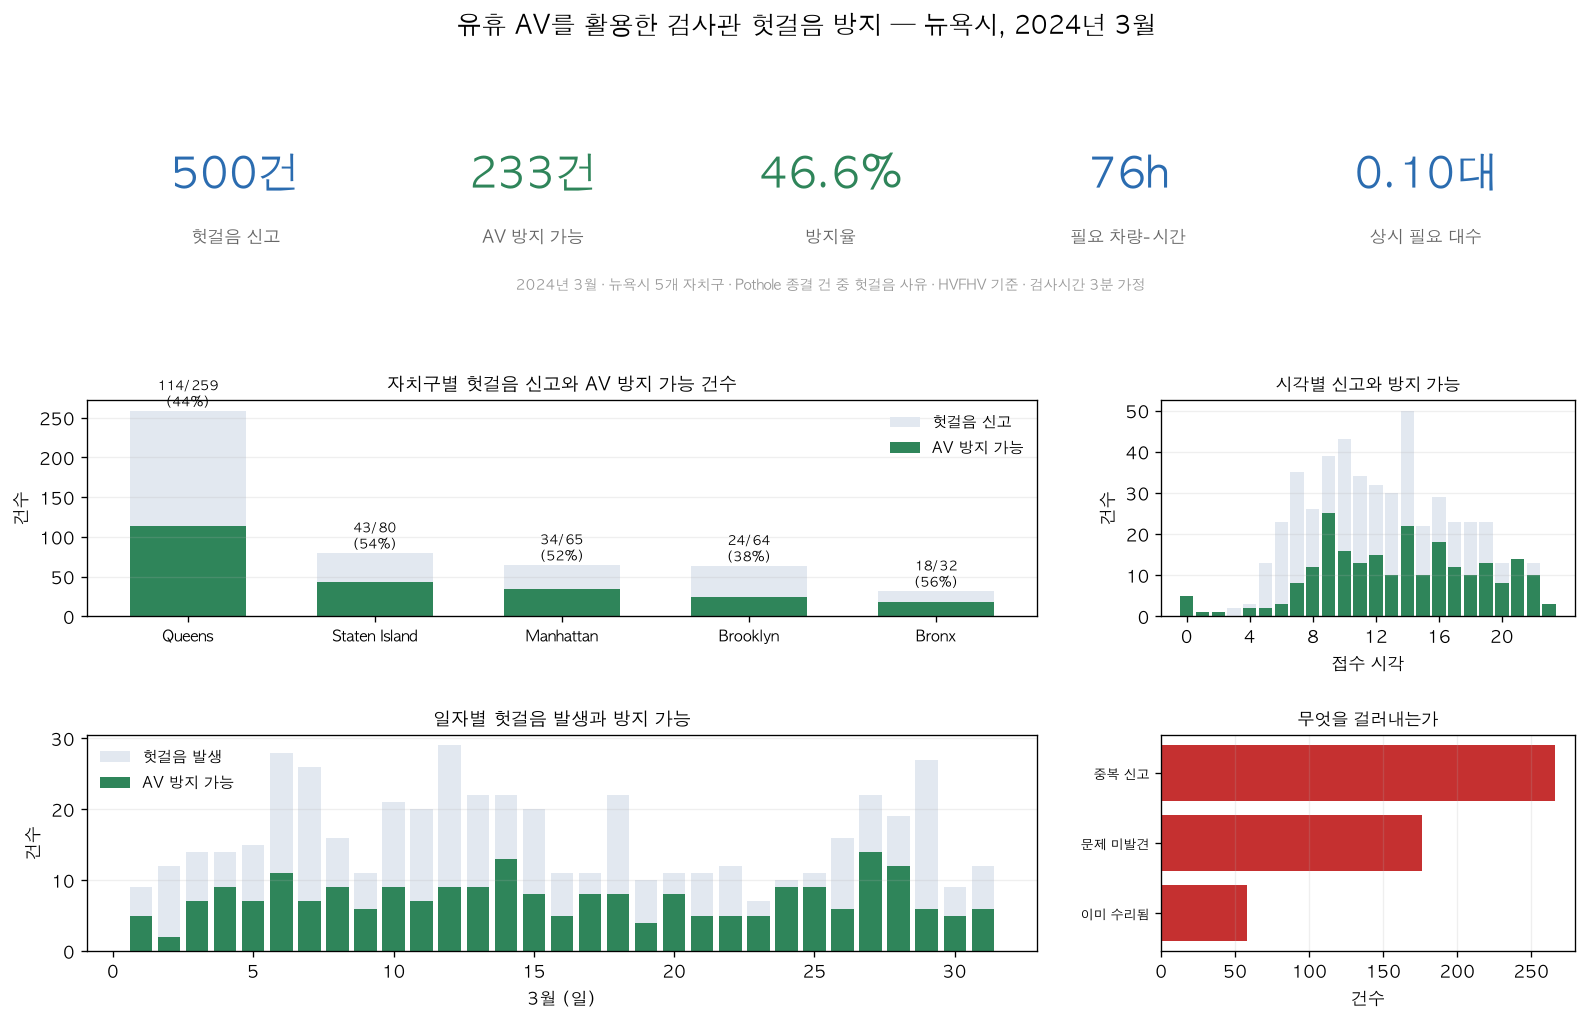

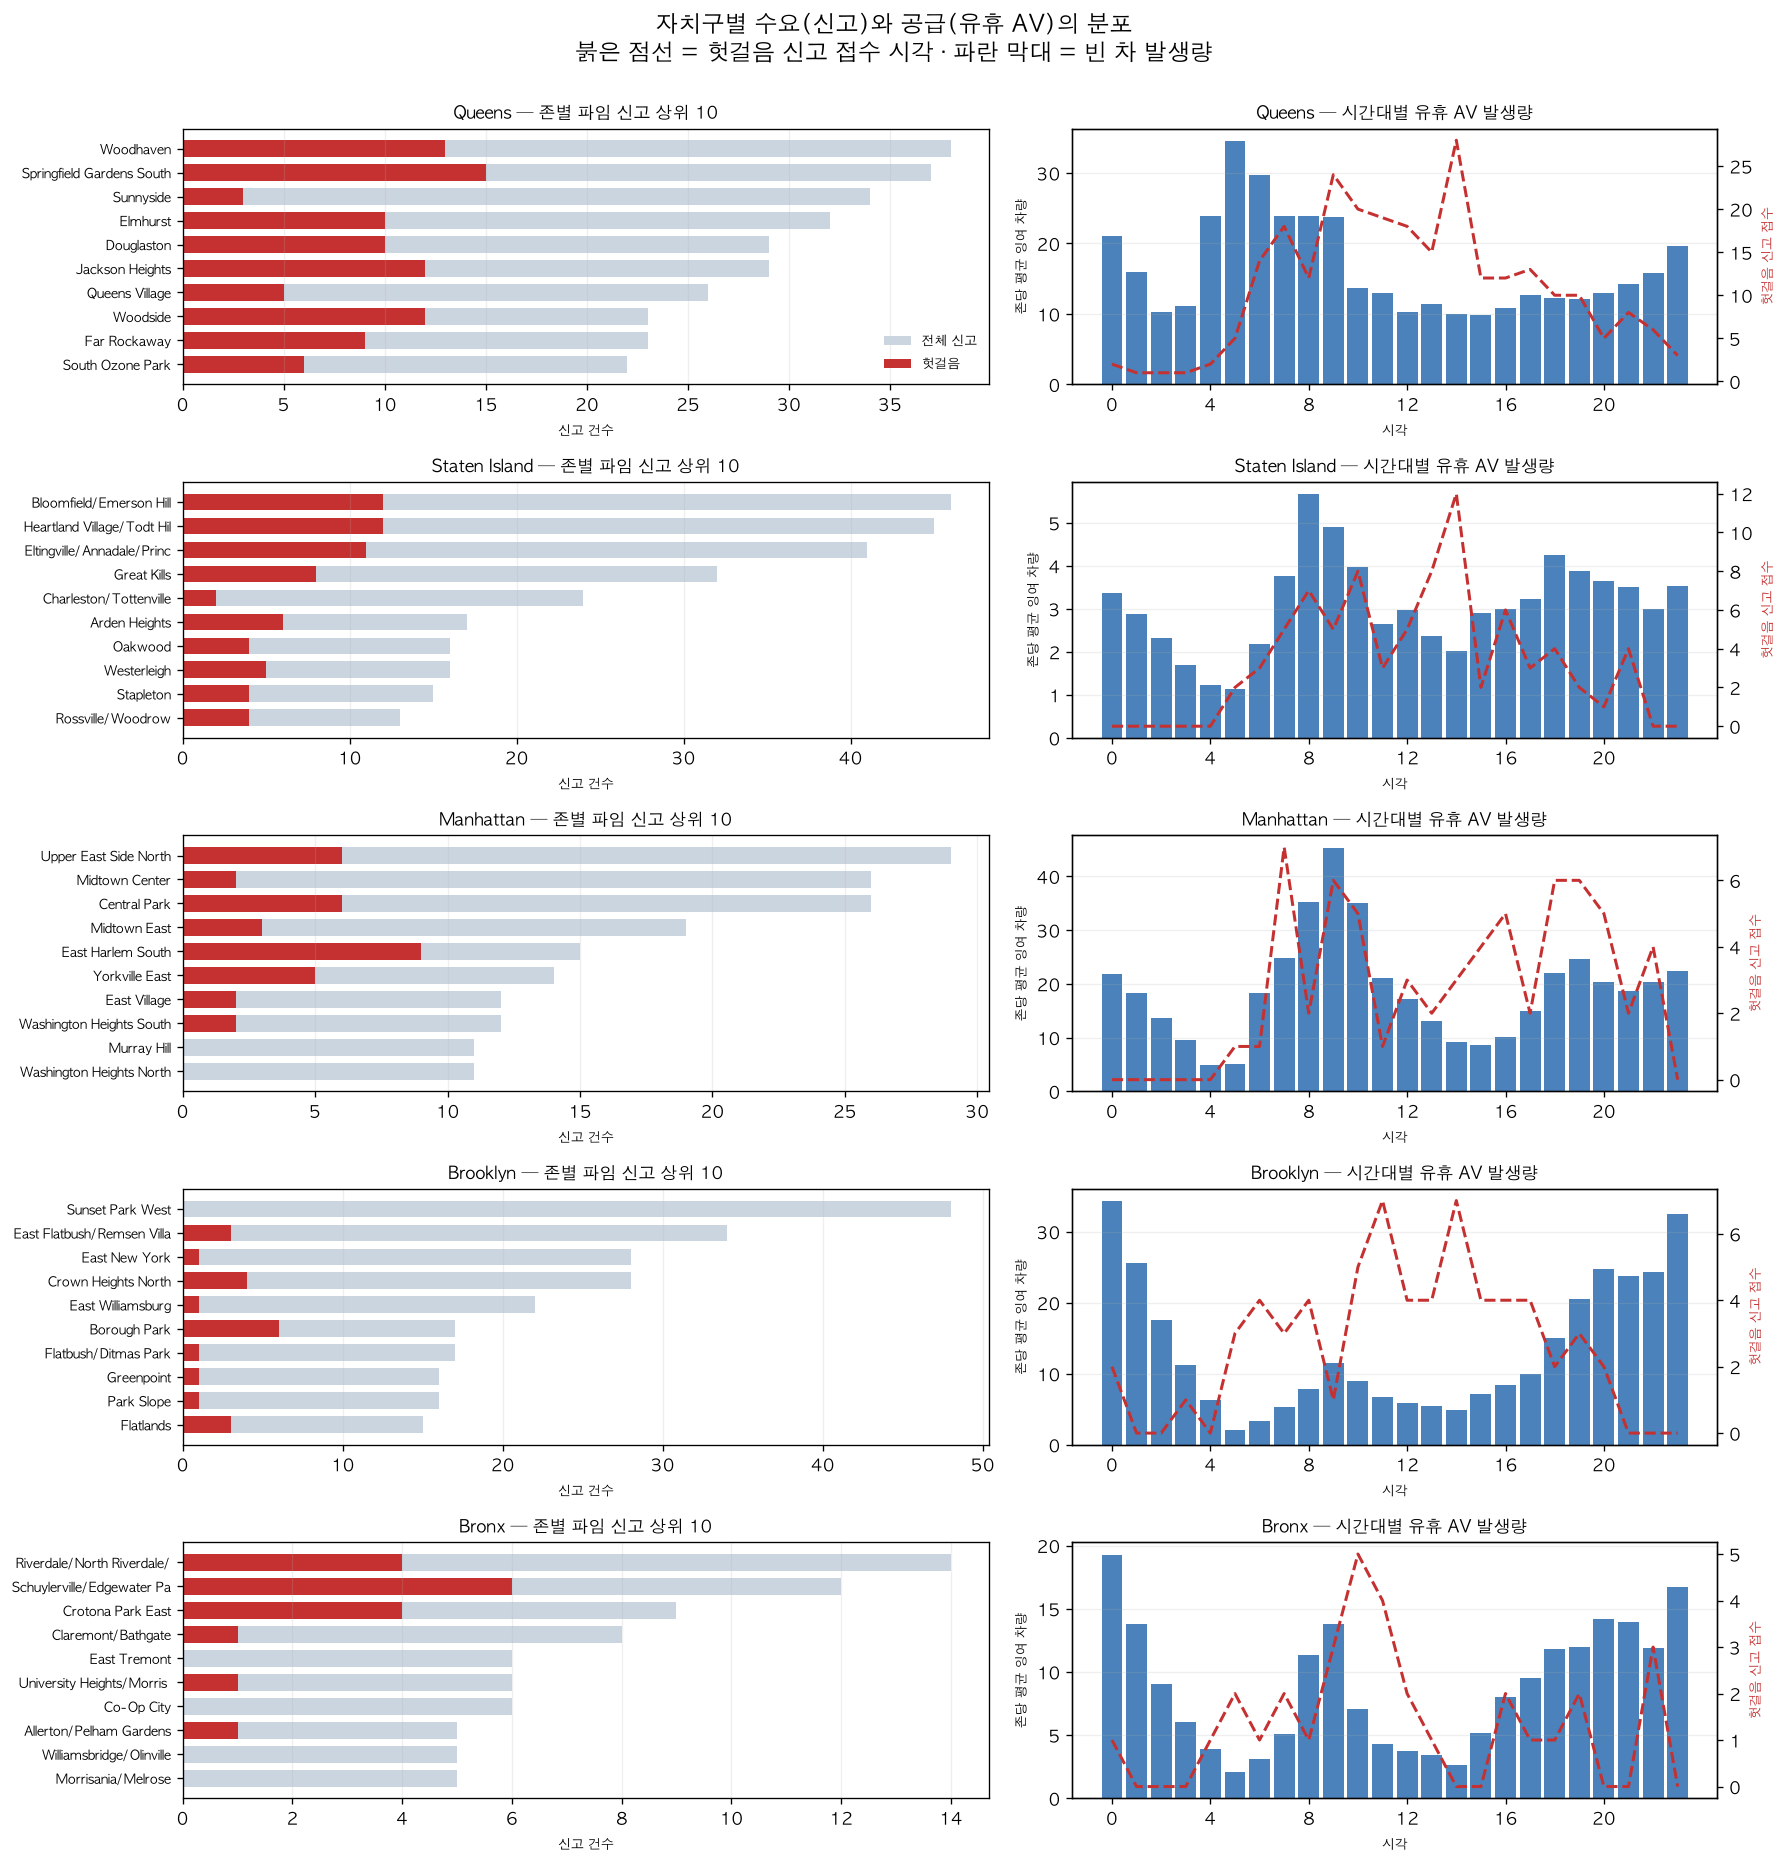

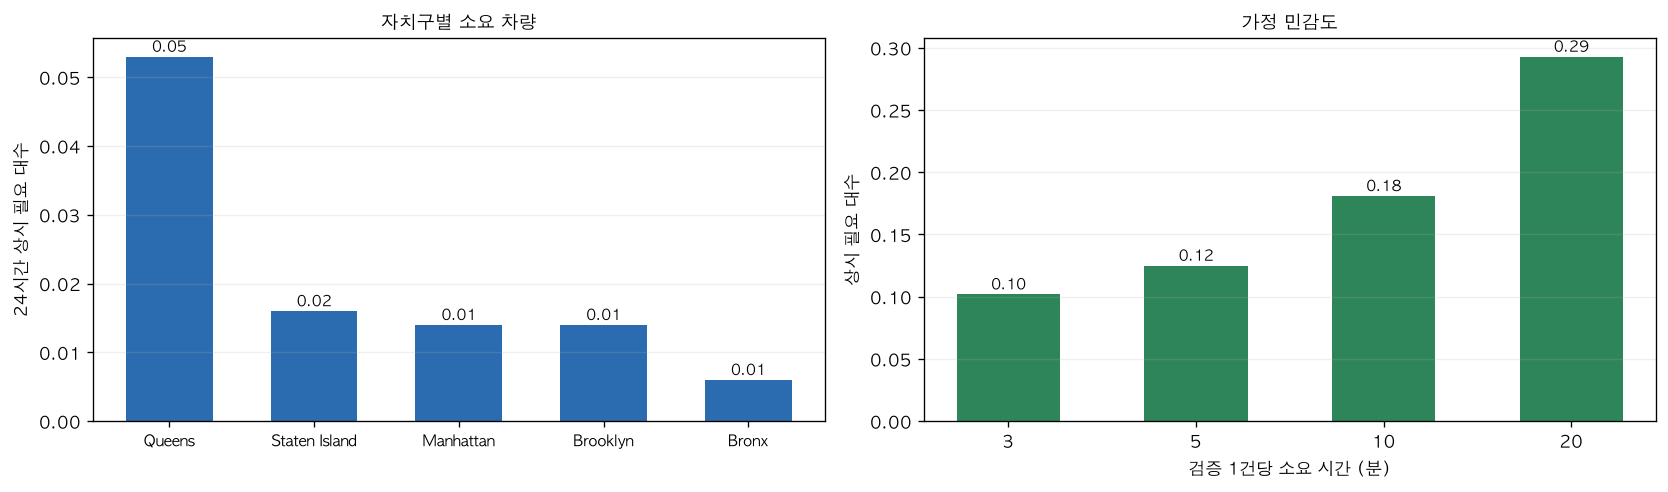

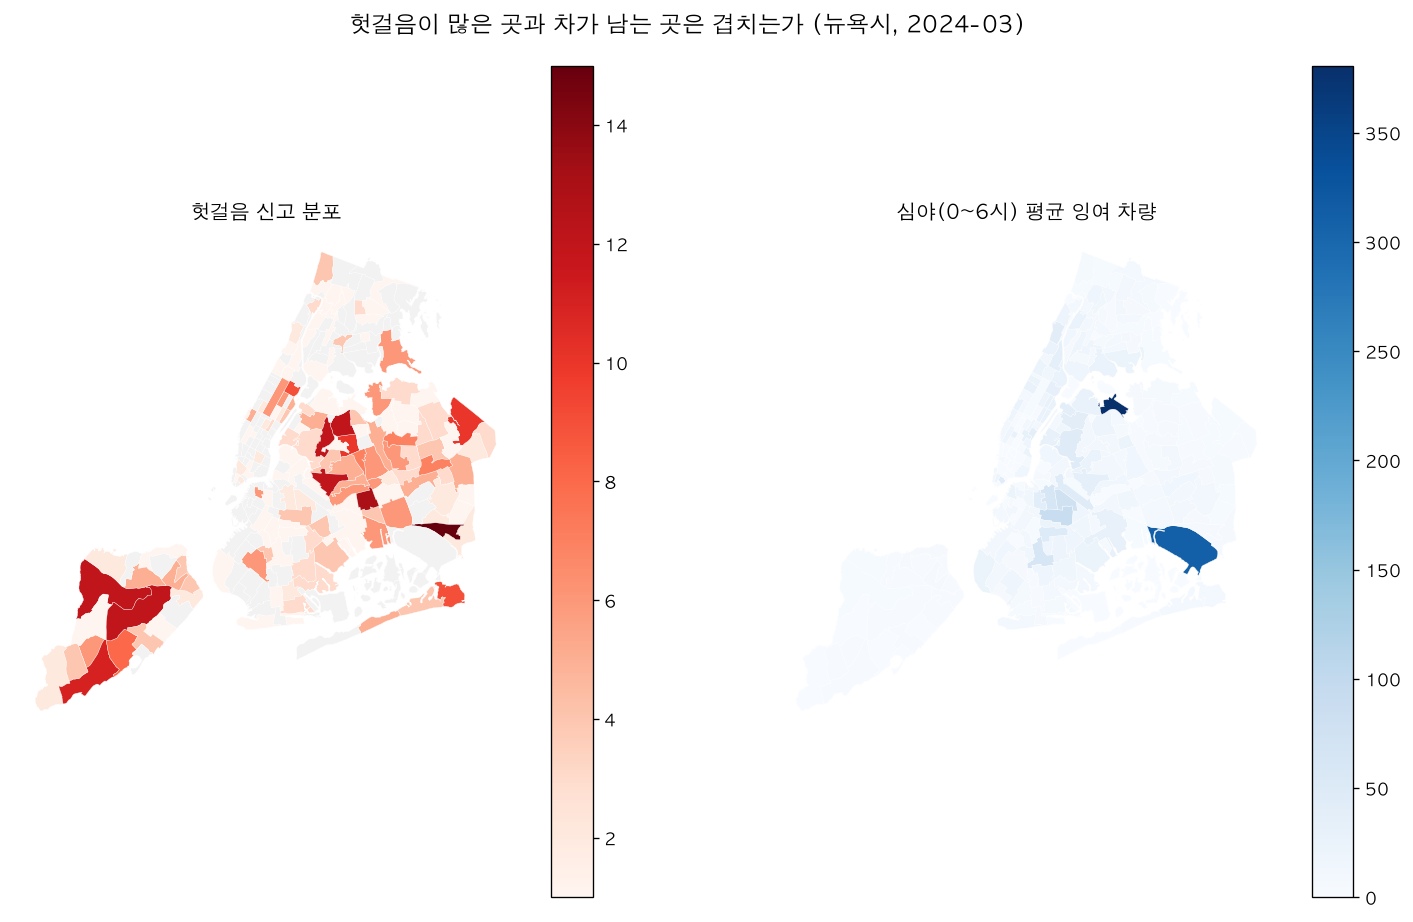

[C16] 저장 완료 → output/


In [1]:
# %% [markdown]
# W4M2 — 뉴욕시 5개 자치구 확장판
# ================================================================
# 유휴 AV를 활용한 검사관 "헛걸음 출동" 방지 서비스
#
# 데이터
#   공급  HVFHV(Uber/Lyft) 트립 기록 2024-03  ← 옐로캡은 맨해튼 밖을 못 다녀서 교체
#   수요  311 파임 신고 2024-03, descriptor = Pothole, status = Closed
#   범위  5개 자치구 · 택시 존 263개
#
# 핵심 정의 (앞선 버전에서 바뀐 점)
#   유휴 판정을 추정값이 아니라 관측값으로 바꿨다.
#     잉여(z,t) = 하차(z,t) − 승차(z,t)
#     → 그 시각 그 존에서 실제로 빈 차가 남았는가
#   이전의 zone_peak − occupied 방식은 존 월간 최댓값을 분모로 삼아
#   거의 모든 슬롯에서 유휴>0이 되어 커버율이 100%로 나오는 결함이 있었다.
#
# 결론 형태
#   자치구별로 "헛걸음 신고 몇 건을 AV가 방지할 수 있었는가"
#   그리고 자치구마다 수요(신고)와 공급(유휴)이 어떻게 어긋나는가

# %%
# ================================================================
# [C1] 설정 & Spark 세션
# ================================================================
import os
os.environ["SPARK_LOCAL_IP"] = "127.0.0.1"      # macOS bind 오류 회피, import보다 먼저

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType

BASE = "/Users/admin/Desktop/personal_wiki/missions/W4/"      # 실제 프로젝트 루트로 수정
TRIP_PATH    = f"{BASE}/data/fhvhv_tripdata_2024-03.parquet"
ZONE_PATH    = f"{BASE}/data/taxi_zone_lookup.csv"
POTHOLE_ROOT = f"{BASE}/warehouse/nyc311"
SHAPE_PATH   = f"{BASE}/zones/taxi_zones.shp"
OUT_DIR      = "output"

YEAR, MONTH = 2024, 3
MONTH_START = f"{YEAR}-{MONTH:02d}-01"
N_DAYS = 31

BOROUGHS = ["Manhattan", "Brooklyn", "Queens", "Bronx", "Staten Island"]

MIN_DURATION_MIN, MAX_DURATION_MIN = 1.0, 180.0
MAX_DISTANCE_MI = 100.0
INSPECT_MIN = 3.0          # 검증 1건당 소요 시간(분) — 가정값

spark = (SparkSession.builder
         .appName("av-pothole-nyc")
         .master("local[*]")
         .config("spark.driver.bindAddress", "127.0.0.1")
         .config("spark.driver.host", "localhost")
         .config("spark.driver.memory", "8g")          # HVFHV는 옐로캡의 6배
         .config("spark.sql.shuffle.partitions", "200")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")
os.makedirs(OUT_DIR, exist_ok=True)
print("Spark", spark.version)


# %%
# ================================================================
# [C2] 존 룩업 — 263개 전체 (Unknown 264/265 제외)
#   자치구 구분은 311의 borough/city 컬럼이 아니라 이 룩업을 기준으로 삼는다.
#   신고와 유휴가 같은 기준으로 묶여야 비교가 성립한다.
# ================================================================
zones = (
    spark.read.option("header", True).csv(ZONE_PATH)
    .select(F.col("LocationID").cast("int").alias("zone_id"),
            F.col("Borough").alias("borough"),
            F.col("Zone").alias("zone_name"))
    .filter(F.col("borough").isin(BOROUGHS))
    .cache()
)

zone_ids = [r["zone_id"] for r in zones.select("zone_id").collect()]
print(f"[C2] 대상 존 {len(zone_ids)}개")
zones.groupBy("borough").count().orderBy(F.desc("count")).show()


# %%
# ================================================================
# [C3] HVFHV 트립 로드 & 정제
#   옐로캡과 컬럼명이 다르다: pickup_datetime / dropoff_datetime / trip_miles
# ================================================================
trips_raw = spark.read.parquet(TRIP_PATH).select(
    F.col("pickup_datetime").alias("pickup_ts"),
    F.col("dropoff_datetime").alias("dropoff_ts"),
    F.col("PULocationID").cast("int").alias("pu_zone"),
    F.col("DOLocationID").cast("int").alias("do_zone"),
    F.col("trip_miles").cast("double").alias("distance"),
)

trips = (
    trips_raw
    .filter((F.year("pickup_ts") == YEAR) & (F.month("pickup_ts") == MONTH))
    .withColumn("duration_min",
                F.expr("timestampdiff(SECOND, pickup_ts, dropoff_ts)") / 60.0)
    .filter(F.col("duration_min").between(MIN_DURATION_MIN, MAX_DURATION_MIN))
    .filter(F.col("distance").between(0.01, MAX_DISTANCE_MI))
    .filter(F.col("pu_zone").isin(zone_ids) & F.col("do_zone").isin(zone_ids))
)

print(f"[C3] 원본 {trips_raw.count():,} → 정제 후 {trips.count():,}")
# ※ 2천만 행대라 캐시하지 않는다. 아래에서 곧바로 집계해 크기를 줄인다.


# %%
# ================================================================
# [C4] 승·하차 집계 → 잉여(빈 차 발생량)
#   하차 = 그 존에서 빈 차가 생긴 사건 (관측)
#   승차 = 빈 차가 소진된 사건 (관측)
#   잉여 = 하차 − 승차 > 0 이면 그 시각 그 존에 차가 남았다
# ================================================================
pickups = (trips
    .withColumn("date", F.to_date("pickup_ts"))
    .withColumn("hour", F.hour("pickup_ts"))
    .groupBy("date", "hour", F.col("pu_zone").alias("zone_id"))
    .agg(F.count("*").alias("pickups")))

dropoffs = (trips
    .withColumn("date", F.to_date("dropoff_ts"))
    .withColumn("hour", F.hour("dropoff_ts"))
    .groupBy("date", "hour", F.col("do_zone").alias("zone_id"))
    .agg(F.count("*").alias("dropoffs")))

# 트립이 0건인 슬롯도 행으로 존재해야 한다
dates = spark.range(N_DAYS).select(
    F.date_add(F.lit(MONTH_START).cast("date"), F.col("id").cast("int")).alias("date")
).filter(F.month("date") == MONTH)
hours = spark.range(24).select(F.col("id").cast("int").alias("hour"))
grid = dates.crossJoin(hours).crossJoin(zones.select("zone_id"))

supply = (
    grid.join(pickups,  ["date", "hour", "zone_id"], "left")
        .join(dropoffs, ["date", "hour", "zone_id"], "left")
        .fillna(0, subset=["pickups", "dropoffs"])
        .withColumn("surplus", F.col("dropoffs") - F.col("pickups"))
        .withColumn("free_vehicles", F.greatest(F.col("surplus"), F.lit(0)))
        .join(zones, "zone_id")
        .cache()
)

print(f"[C4] supply {supply.count():,} 행 "
      f"(31일 × 24시 × {len(zone_ids)}존)")

FREE_POOL = supply.agg(F.sum("free_vehicles")).first()[0]
print(f"     3월 총 잉여 차량 발생 {FREE_POOL:,.0f} 대-시간")


# %%
# ================================================================
# [C5] 점유 차량 수 → 자치구별 시간대 프로파일
#   슬롯 펼치기: 09:50~10:30 트립 → 9시에 10분, 10시에 30분
# ================================================================
occ_zone_slot = (
    trips
    .withColumn("pu_hr", F.date_trunc("hour", "pickup_ts"))
    .withColumn("do_hr", F.date_trunc("hour", "dropoff_ts"))
    .withColumn("slot", F.explode(F.expr("sequence(pu_hr, do_hr, interval 1 hour)")))
    .withColumn("slot_end", F.expr("slot + interval 1 hour"))
    .withColumn("ov_start", F.greatest("pickup_ts", "slot"))
    .withColumn("ov_end",   F.least("dropoff_ts", "slot_end"))
    .withColumn("busy_min", F.expr("timestampdiff(SECOND, ov_start, ov_end)") / 60.0)
    .filter(F.col("busy_min") > 0)
    .groupBy("slot", F.col("pu_zone").alias("zone_id"))
    .agg((F.sum("busy_min") / 60.0).alias("occupied"))
    .cache()
)

w_boro = Window.partitionBy("borough")

hourly_boro = (
    occ_zone_slot.join(zones, "zone_id")
    .withColumn("hour", F.hour("slot"))
    .groupBy("borough", "hour")
    .agg(F.avg("occupied").alias("occupied"))     # 존 평균이 아니라 슬롯 평균
    .withColumn("peak", F.max("occupied").over(w_boro))
    .withColumn("idle_rate", F.lit(1.0) - F.col("occupied") / F.col("peak"))
    .cache()
)

print(f"[C5] occ_zone_slot {occ_zone_slot.count():,} 행")


# %%
# ================================================================
# [C6] 존 내부 이동시간 → 처리율
#   외곽 자치구 존은 면적이 커서 이 값이 크게 나온다 (= 검증 효율 낮음)
# ================================================================
intra = (
    trips.filter(F.col("pu_zone") == F.col("do_zone"))
    .groupBy(F.col("pu_zone").alias("zone_id"))
    .agg(F.expr("percentile_approx(duration_min, 0.5)").alias("intra_min"),
         F.count("*").alias("n_intra"))
    .cache()
)

DEFAULT_INTRA = intra.agg(F.expr("percentile_approx(intra_min, 0.5)")).first()[0]

intra.join(zones, "zone_id").groupBy("borough") \
     .agg(F.round(F.avg("intra_min"), 1).alias("존내이동_분_평균")) \
     .orderBy("존내이동_분_평균").show()
print(f"[C6] 전체 중앙값 {DEFAULT_INTRA:.1f}분 (결측 존 기본값)")


# %%
# ================================================================
# [C7] 311 파임 신고 로드 & 헛걸음 라벨링
# ================================================================
WASTED_KEYWORDS = [
    "determined that this complaint is a duplicate",               # 중복 신고
    "did not find the reported problem",                           # 문제 미발견
    "found that the problem was fixed",                            # 이미 수리됨
    "in compliance with Department of Transportation standards",   # 기준 부합·비위험
    "not within its jurisdiction",                                 # 소관 아님 (MTA 포함)
    "referred it to the Arterial Division",                        # 타 부서 이관
    "referred it to the Bridge Division",
    "reported condition was not found",                            # 상태 미발견, 무조치
]


def make_wasted_expr(col_name):
    """컬럼명을 인자로 받아 원본/별칭 양쪽에서 재사용 가능하게 한다."""
    e = F.lit(False)
    for kw in WASTED_KEYWORDS:
        e = e | F.coalesce(F.col(col_name).contains(kw), F.lit(False))
    return e


created_expr = F.coalesce(
    F.to_timestamp("created_date", "yyyy-MM-dd'T'HH:mm:ss.SSS"),
    F.to_timestamp("created_date", "yyyy-MM-dd HH:mm:ss"),
    F.to_timestamp("created_date", "MM/dd/yyyy hh:mm:ss a"),
    F.col("created_date").cast("timestamp"),
)

rep_raw = (spark.read.parquet(POTHOLE_ROOT)
           .filter((F.col("year") == YEAR) & (F.col("month") == MONTH)))

rep = (
    rep_raw
    .filter(F.col("agency") == "DOT")
    .filter(F.col("descriptor") == "Pothole")      # 정확 일치 (Pothole - Highway 배제)
    .filter(F.lower(F.col("status")) == "closed")
    .select(
        F.col("unique_key").cast("string").alias("report_id"),
        created_expr.alias("created_ts"),
        F.col("latitude").cast("double").alias("lat"),
        F.col("longitude").cast("double").alias("lon"),
        F.col("resolution_description").alias("resolution"),
    )
    .filter(F.col("created_ts").isNotNull())
    .filter(F.col("lat").isNotNull() & F.col("lon").isNotNull())
    .withColumn("date", F.to_date("created_ts"))
    .withColumn("hour", F.hour("created_ts"))
    .withColumn("is_wasted", make_wasted_expr("resolution").cast("int"))
    .cache()
)

print(f"[C7] 시 전체 Pothole(Closed) {rep.count():,}건 / "
      f"헛걸음 {rep.agg(F.sum('is_wasted')).first()[0]:,}건")
rep.select(F.min("date").alias("최소일"), F.max("date").alias("최대일")).show()


# %%
# ================================================================
# [C8] 좌표 → 택시 존 매핑 (브로드캐스트 UDF)
#   폴리곤이 263개로 늘어 UDF가 느려진다. STRtree 인덱스로 보완한다.
# ================================================================
import geopandas as gpd
from shapely.geometry import Point
from shapely.strtree import STRtree

_shapes = gpd.read_file(SHAPE_PATH).to_crs(epsg=4326)
_shapes["LocationID"] = _shapes["LocationID"].astype(int)
_shapes = _shapes[_shapes["LocationID"].isin(zone_ids)].reset_index(drop=True)

bc_geoms = spark.sparkContext.broadcast(
    [(int(r.LocationID), r.geometry) for r in _shapes.itertuples()])

_tree_cache = {}


@F.udf(IntegerType())
def to_zone(lon, lat):
    if lon is None or lat is None:
        return None
    if "t" not in _tree_cache:                    # 워커별 1회만 인덱스 구축
        geoms = [g for _, g in bc_geoms.value]
        _tree_cache["t"] = STRtree(geoms)
        _tree_cache["ids"] = [i for i, _ in bc_geoms.value]
    p = Point(lon, lat)
    for idx in _tree_cache["t"].query(p):
        if bc_geoms.value[idx][1].contains(p):
            return _tree_cache["ids"][idx]
    return None


reports = (rep.withColumn("zone_id", to_zone("lon", "lat"))
              .filter(F.col("zone_id").isNotNull())
              .join(zones, "zone_id")
              .select("report_id", "date", "hour", "zone_id", "zone_name",
                      "borough", "resolution", "is_wasted")
              .cache())

N_ALL = reports.count()
N_WASTED = reports.agg(F.sum("is_wasted")).first()[0]
print(f"[C8] 존 매핑 {N_ALL:,}건 (실패 {rep.count()-N_ALL:,}건 제외) · "
      f"헛걸음 {N_WASTED:,}건")

reports.groupBy("borough").agg(
    F.count("*").alias("신고"),
    F.sum("is_wasted").alias("헛걸음"),
    F.round(F.avg("is_wasted") * 100, 1).alias("헛걸음율%")
).orderBy(F.desc("신고")).show()


# %%
# ================================================================
# [C9] ★ 헛걸음 방지 가능 여부 판정
#   접수된 그 날짜·시각·존에서 빈 차가 실제로 남았는가 (잉여 ≥ 1)
# ================================================================
wasted_rep = reports.filter(F.col("is_wasted") == 1)

cover = (
    wasted_rep
    .join(supply.select("date", "hour", "zone_id",
                        "pickups", "dropoffs", "surplus", "free_vehicles"),
          ["date", "hour", "zone_id"], "left")
    .fillna(0, ["pickups", "dropoffs", "surplus", "free_vehicles"])
    .withColumn("coverable", (F.col("surplus") >= 1).cast("int"))
    .cache()
)

PREVENTED = cover.agg(F.sum("coverable")).first()[0]

print("=" * 66)
print(f"  헛걸음 확정 신고        {N_WASTED:>8,} 건")
print(f"  AV로 방지 가능          {PREVENTED:>8,} 건  ({PREVENTED/N_WASTED*100:.1f}%)")
print("=" * 66)

cover.groupBy("borough").agg(
    F.count("*").alias("헛걸음"),
    F.sum("coverable").alias("방지가능"),
    F.round(F.avg("coverable") * 100, 1).alias("방지율%")
).orderBy(F.desc("헛걸음")).show()

cover.groupBy("hour").agg(
    F.count("*").alias("신고"),
    F.sum("coverable").alias("방지"),
    F.round(F.avg("coverable") * 100, 1).alias("방지율%")
).orderBy("hour").show(24)


# %%
# ================================================================
# [C10] 소요 자원 — 자치구별
# ================================================================
def resource_by_boro(inspect_min):
    return (wasted_rep.groupBy("borough", "zone_id").agg(F.count("*").alias("n"))
            .join(intra.select("zone_id", "intra_min"), "zone_id", "left")
            .fillna(DEFAULT_INTRA, ["intra_min"])
            .withColumn("veh_h", F.col("n") * (F.col("intra_min") + inspect_min) / 60.0)
            .groupBy("borough")
            .agg(F.sum("n").alias("헛걸음"),
                 F.round(F.sum("veh_h"), 1).alias("필요차량시간"),
                 F.round(F.sum("veh_h") / (N_DAYS * 24), 3).alias("상시필요대수")))


res_boro = resource_by_boro(INSPECT_MIN).cache()
res_boro.orderBy(F.desc("헛걸음")).show()

NEED_H = res_boro.agg(F.sum("필요차량시간")).first()[0]
print(f"[C10] 전체 필요 차량-시간 {NEED_H:,.1f} h · "
      f"총 잉여 대비 {NEED_H/FREE_POOL*100:.4f}%")

sens_rows = []
for m in [3.0, 5.0, 10.0, 20.0]:
    h = resource_by_boro(m).agg(F.sum("필요차량시간")).first()[0]
    sens_rows.append((m, round(h, 1), round(h / (N_DAYS * 24), 3)))
sens = spark.createDataFrame(sens_rows, ["검사시간_분", "필요차량시간", "상시필요대수"])
sens.show(truncate=False)


# %%
# ================================================================
# [C11] 시각화 준비 — 여기서만 toPandas
# ================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.colors import TwoSlopeNorm

FONT = None
for cand in ["AppleGothic", "Malgun Gothic", "NanumGothic"]:
    if any(f.name == cand for f in fm.fontManager.ttflist):
        FONT = cand
        plt.rcParams["font.family"] = cand
        break
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120
BOLD = "normal" if FONT == "AppleGothic" else "bold"   # AppleGothic엔 bold가 없다

cover_pd = cover.toPandas()
cover_pd["date"] = pd.to_datetime(cover_pd["date"])
cover_pd["day"] = cover_pd["date"].dt.day

# 존별 신고 (모든 신고 / 헛걸음 구분)
zone_rep_pd = (reports.groupBy("borough", "zone_id", "zone_name")
               .agg(F.count("*").alias("reports"),
                    F.sum("is_wasted").alias("wasted"))
               .toPandas())

# 자치구 × 시간대 잉여 (유휴 AV 발생량)
boro_supply_pd = (supply.groupBy("borough", "hour")
                  .agg(F.avg("free_vehicles").alias("free_avg"),
                       F.avg("surplus").alias("surplus_avg"),
                       F.avg("dropoffs").alias("drop_avg"))
                  .toPandas())

boro_res_pd  = res_boro.toPandas()
hourly_pd    = hourly_boro.toPandas()
sens_pd      = sens.toPandas()

BORO_ORDER = (cover_pd.groupby("borough").size()
              .sort_values(ascending=False).index.tolist())
print(BORO_ORDER)


# %%
# ================================================================
# [C12] ★ 메인 대시보드 — AV로 얼마나 대체하는가
# ================================================================
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(3, 3, height_ratios=[0.75, 1, 1], hspace=0.6, wspace=0.3)

# ── 상단 KPI ──
ax = fig.add_subplot(gs[0, :]); ax.axis("off")
kpis = [("헛걸음 신고", f"{N_WASTED:,}건"),
        ("AV 방지 가능", f"{PREVENTED:,}건"),
        ("방지율", f"{PREVENTED/N_WASTED*100:.1f}%"),
        ("필요 차량-시간", f"{NEED_H:,.0f}h"),
        ("상시 필요 대수", f"{NEED_H/(N_DAYS*24):.2f}대")]
for i, (label, val) in enumerate(kpis):
    x = 0.1 + i * 0.2
    c = "#2f855a" if i in (1, 2) else "#2b6cb0"
    ax.text(x, 0.58, val, ha="center", fontsize=25, weight=BOLD, color=c)
    ax.text(x, 0.24, label, ha="center", fontsize=10, color="#666")
ax.text(0.5, -0.05,
        f"2024년 3월 · 뉴욕시 5개 자치구 · Pothole 종결 건 중 헛걸음 사유 · "
        f"HVFHV 기준 · 검사시간 {INSPECT_MIN:.0f}분 가정",
        ha="center", fontsize=8.5, color="#999")

# ── 중단 좌: 자치구별 헛걸음 vs 방지 ──
ax = fig.add_subplot(gs[1, :2])
bb = (cover_pd.groupby("borough")
      .agg(total=("coverable", "size"), ok=("coverable", "sum"))
      .reindex(BORO_ORDER))
x = np.arange(len(bb))
ax.bar(x, bb["total"], width=0.62, color="#e2e8f0", label="헛걸음 신고")
ax.bar(x, bb["ok"], width=0.62, color="#2f855a", label="AV 방지 가능")
for i, (t, o) in enumerate(zip(bb["total"], bb["ok"])):
    ax.text(i, t, f"{o}/{t}\n({o/t*100:.0f}%)", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(bb.index, fontsize=9)
ax.set_ylabel("건수")
ax.set_title("자치구별 헛걸음 신고와 AV 방지 가능 건수", fontsize=11, weight=BOLD)
ax.legend(frameon=False, fontsize=9); ax.grid(axis="y", alpha=0.2)

# ── 중단 우: 접수 시각별 방지율 ──
ax = fig.add_subplot(gs[1, 2])
bh = (cover_pd.groupby("hour")
      .agg(n=("coverable", "size"), ok=("coverable", "sum"))
      .reindex(range(24), fill_value=0))
ax.bar(bh.index, bh["n"], color="#e2e8f0", width=0.85)
ax.bar(bh.index, bh["ok"], color="#2f855a", width=0.85)
ax.set_xticks(range(0, 24, 4)); ax.set_xlabel("접수 시각"); ax.set_ylabel("건수")
ax.set_title("시각별 신고와 방지 가능", fontsize=10, weight=BOLD)
ax.grid(axis="y", alpha=0.2)

# ── 하단 좌: 일자별 ──
ax = fig.add_subplot(gs[2, :2])
bd = (cover_pd.groupby("day")
      .agg(total=("coverable", "size"), ok=("coverable", "sum"))
      .reindex(range(1, N_DAYS + 1), fill_value=0))
ax.bar(bd.index, bd["total"], color="#e2e8f0", width=0.8, label="헛걸음 발생")
ax.bar(bd.index, bd["ok"], color="#2f855a", width=0.8, label="AV 방지 가능")
ax.set_xlabel("3월 (일)"); ax.set_ylabel("건수")
ax.set_title("일자별 헛걸음 발생과 방지 가능", fontsize=11, weight=BOLD)
ax.legend(frameon=False, fontsize=9); ax.grid(axis="y", alpha=0.2)

# ── 하단 우: 헛걸음 사유 ──
ax = fig.add_subplot(gs[2, 2])
def short_reason(t):
    for k, v in [("duplicate", "중복 신고"), ("did not find", "문제 미발견"),
                 ("problem was fixed", "이미 수리됨"), ("compliance", "기준 부합"),
                 ("jurisdiction", "소관 아님"), ("Arterial", "간선과"),
                 ("Bridge Division", "교량과"), ("condition was not found", "상태 미발견")]:
        if k in str(t):
            return v
    return "기타"
rc = cover_pd["resolution"].map(short_reason).value_counts()
ax.barh(range(len(rc)), rc.values, color="#c53030")
ax.set_yticks(range(len(rc))); ax.set_yticklabels(rc.index, fontsize=8)
ax.invert_yaxis(); ax.set_xlabel("건수")
ax.set_title("무엇을 걸러내는가", fontsize=10, weight=BOLD)
ax.grid(axis="x", alpha=0.2)

fig.suptitle("유휴 AV를 활용한 검사관 헛걸음 방지 — 뉴욕시, 2024년 3월",
             fontsize=15, weight=BOLD, y=0.98)
plt.show()


# %%
# ================================================================
# [C13] ★ 자치구별 상세 — (좌) 존별 신고 · (우) 시간대별 유휴 AV
# ================================================================
fig, axes = plt.subplots(len(BORO_ORDER), 2, figsize=(15, 3.1 * len(BORO_ORDER)),
                         gridspec_kw={"width_ratios": [1.25, 1]})

for i, boro in enumerate(BORO_ORDER):
    # ── 좌: 존별 파임 신고 건수 (상위 10) ──
    ax = axes[i, 0]
    zb = (zone_rep_pd[zone_rep_pd["borough"] == boro]
          .nlargest(10, "reports").sort_values("reports"))
    y = np.arange(len(zb))
    ax.barh(y, zb["reports"], color="#cbd5e0", height=0.7, label="전체 신고")
    ax.barh(y, zb["wasted"], color="#c53030", height=0.7, label="헛걸음")
    ax.set_yticks(y)
    ax.set_yticklabels([z[:26] for z in zb["zone_name"]], fontsize=7.5)
    ax.set_xlabel("신고 건수", fontsize=8)
    ax.set_title(f"{boro} — 존별 파임 신고 상위 10", fontsize=10, weight=BOLD)
    ax.grid(axis="x", alpha=0.2)
    if i == 0:
        ax.legend(frameon=False, fontsize=8, loc="lower right")

    # ── 우: 시간대별 유휴 AV (잉여 차량) ──
    ax = axes[i, 1]
    sb = (boro_supply_pd[boro_supply_pd["borough"] == boro]
          .set_index("hour").reindex(range(24)).fillna(0))
    ax.bar(sb.index, sb["free_avg"], color="#2b6cb0", width=0.85, alpha=0.85)
    ax.set_xticks(range(0, 24, 4)); ax.set_xlabel("시각", fontsize=8)
    ax.set_ylabel("존당 평균 잉여 차량", fontsize=8)
    ax.set_title(f"{boro} — 시간대별 유휴 AV 발생량", fontsize=10, weight=BOLD)
    ax.grid(axis="y", alpha=0.2)

    # 그 자치구 헛걸음 신고 접수 시각을 겹쳐 표시
    ax2 = ax.twinx()
    ch = (cover_pd[cover_pd["borough"] == boro].groupby("hour").size()
          .reindex(range(24), fill_value=0))
    ax2.plot(ch.index, ch.values, lw=1.8, ls="--", color="#c53030")
    ax2.set_ylabel("헛걸음 신고 접수", fontsize=8, color="#c53030")

fig.suptitle("자치구별 수요(신고)와 공급(유휴 AV)의 분포\n"
             "붉은 점선 = 헛걸음 신고 접수 시각 · 파란 막대 = 빈 차 발생량",
             fontsize=14, weight=BOLD, y=1.0)
fig.tight_layout(); plt.show()


# %%
# ================================================================
# [C14] 부록 A — 자치구별 소요 자원 & 가정 민감도
# ================================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

ax = axes[0]
br = boro_res_pd.set_index("borough").reindex(BORO_ORDER)
ax.bar(range(len(br)), br["상시필요대수"], color="#2b6cb0", width=0.6)
for i, v in enumerate(br["상시필요대수"]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(range(len(br))); ax.set_xticklabels(br.index, fontsize=9)
ax.set_ylabel("24시간 상시 필요 대수")
ax.set_title("자치구별 소요 차량", fontsize=11, weight=BOLD)
ax.grid(axis="y", alpha=0.2)

ax = axes[1]
ax.bar(sens_pd["검사시간_분"].astype(int).astype(str),
       sens_pd["상시필요대수"], color="#2f855a", width=0.55)
for i, v in enumerate(sens_pd["상시필요대수"]):
    ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("검증 1건당 소요 시간 (분)"); ax.set_ylabel("상시 필요 대수")
ax.set_title("가정 민감도", fontsize=11, weight=BOLD)
ax.grid(axis="y", alpha=0.2)

fig.tight_layout(); plt.show()


# %%
# ================================================================
# [C15] 부록 B — 뉴욕시 지도 (헛걸음 분포 vs 유휴 분포)
# ================================================================
gdf = _shapes.rename(columns={"LocationID": "zone_id"})[["zone_id", "geometry"]]

fig, axes = plt.subplots(1, 2, figsize=(15, 9))

wz = (cover_pd.groupby("zone_id").size().rename("wasted").reset_index())
gdf.merge(wz, on="zone_id", how="left").plot(
    column="wasted", cmap="Reds", linewidth=0.2, edgecolor="white",
    ax=axes[0], legend=True, missing_kwds={"color": "#f2f2f2"})
axes[0].set_title("헛걸음 신고 분포", fontsize=12, weight=BOLD); axes[0].set_axis_off()

night = (boro_supply_pd if False else None)  # placeholder 방지
zone_night = (supply.filter(F.col("hour").between(0, 5))
              .groupBy("zone_id").agg(F.avg("free_vehicles").alias("free_night"))
              .toPandas())
gdf.merge(zone_night, on="zone_id", how="left").plot(
    column="free_night", cmap="Blues", linewidth=0.2, edgecolor="white",
    ax=axes[1], legend=True, missing_kwds={"color": "#f2f2f2"})
axes[1].set_title("심야(0~6시) 평균 잉여 차량", fontsize=12, weight=BOLD)
axes[1].set_axis_off()

fig.suptitle("헛걸음이 많은 곳과 차가 남는 곳은 겹치는가 (뉴욕시, 2024-03)",
             fontsize=14, weight=BOLD, y=0.93)
plt.show()


# %%
# ================================================================
# [C16] 저장 & 세션 종료
# ================================================================
cover.select("report_id", "date", "hour", "zone_id", "zone_name", "borough",
             "pickups", "dropoffs", "surplus", "coverable", "resolution") \
     .coalesce(1).write.mode("overwrite").option("header", True) \
     .csv(f"{OUT_DIR}/nyc_wasted_coverage")

cover_pd.to_csv(f"{OUT_DIR}/nyc_wasted_coverage.csv", index=False)
zone_rep_pd.to_csv(f"{OUT_DIR}/nyc_zone_reports.csv", index=False)
boro_supply_pd.to_csv(f"{OUT_DIR}/nyc_boro_supply.csv", index=False)

print(f"[C16] 저장 완료 → {OUT_DIR}/")
spark.stop()